# Распространение доверия

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Вероятностный связный классификатор

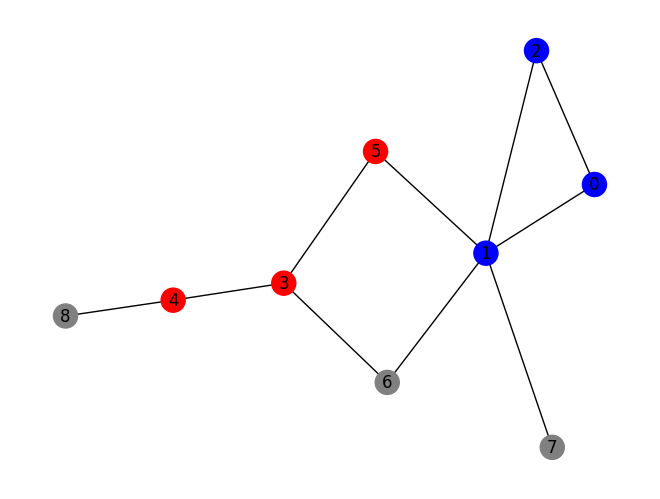

In [2]:
G=nx.Graph()
G.add_nodes_from([(0,{'Y':1,'train':1}),(1,{'Y':1,'train':1}),(2,{'Y':1,'train':1}),
                  (3,{'Y':0,'train':1}),(4,{'Y':0,'train':1}),(5,{'Y':0,'train':1}),
                  (6,{'Y':-1,'train':0}),(7,{'Y':-1,'train':0}),(8,{'Y':-1,'train':0}),
                  ])
G.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(3,6),(1,5),(1,6),(1,7),(4,8)])
cols={-1:'gray',0:'red',1:'blue'}
c = []
for node,attr in G.nodes.items():
    c.append(cols[attr['Y']])
pos=nx.kamada_kawai_layout(G)
nx.draw(G, pos,node_color=c, with_labels=True)

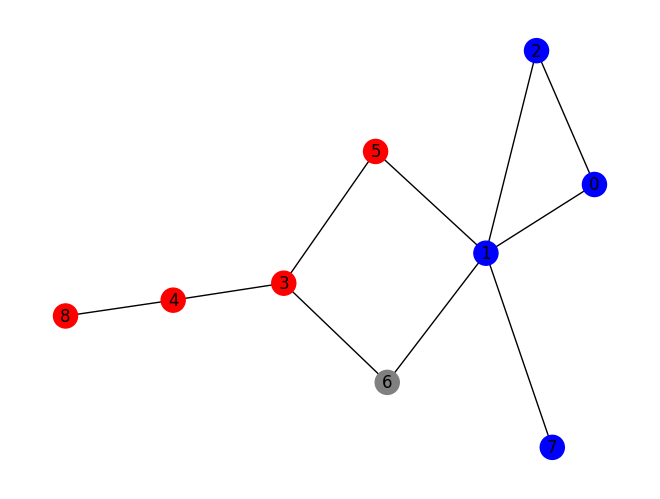

In [3]:
import random as rd
for node in G.nodes():
    if G.nodes[node]['train']==0: G.nodes[node]['Y']=0.5
for itt in range(1000):
 n=rd.choice(list(G.nodes()))
 w=[]
 for n_n in G.neighbors(n): w.append(G.nodes[n_n]['Y'])
 w=np.array(w)
 if(G.nodes[n]['train']==0): G.nodes[n]['Y']=w.mean()
c = []
for node,attr in G.nodes.items():
  if attr['Y']>0.5: c.append(cols[1])
  elif attr['Y']<0.5: c.append(cols[0])
  else: c.append('gray')
nx.draw(G, pos,node_color=c, with_labels=True)

## Itterative classifier

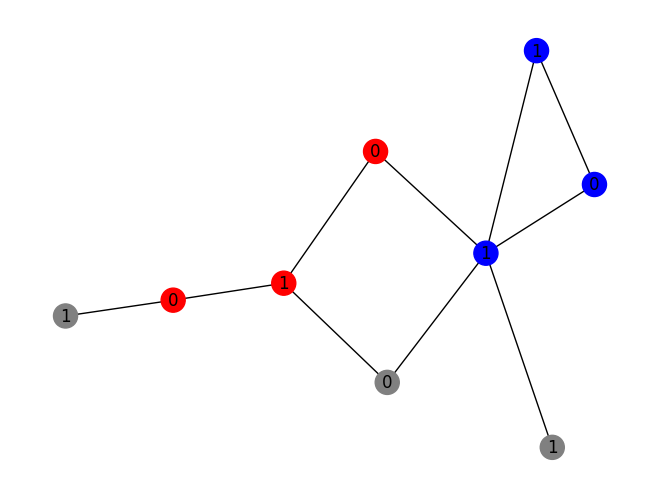

In [5]:
import networkx as nx
G=nx.Graph()
G.add_nodes_from([(0,{'Y':1,'train':1,'F':0}),(1,{'Y':1,'train':1,'F':1}),(2,{'Y':1,'train':1,'F':1}),
                  (3,{'Y':0,'train':1,'F':1}),(4,{'Y':0,'train':1,'F':0}),(5,{'Y':0,'train':1,'F':0}),
                  (6,{'Y':-1,'train':0,'F':0}),(7,{'Y':-1,'train':0,'F':1}),(8,{'Y':-1,'train':0,'F':1}),
                  ])
G.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(3,6),(1,5),(1,6),(1,7),(4,8)])
cols={-1:'gray',0:'red',1:'blue'}
c = []
for node,attr in G.nodes.items():
    c.append(cols[attr['Y']])

labeldict = {}
for node,attr in G.nodes.items():
    labeldict[node] = attr['F']

pos=nx.kamada_kawai_layout(G)
nx.draw(G, pos,node_color=c, labels=labeldict, with_labels=True)

In [6]:
import numpy as np
### Train F1
x1,y1=[],[]
for n in G.nodes():
  if G.nodes[n]['train']==1:
    x1.append(G.nodes[n]['F'])
    y1.append(G.nodes[n]['Y'])
print(x1,y1)
x1=np.array(x1)[:,np.newaxis]
y1=np.array(y1)

[0, 1, 1, 1, 0, 0] [1, 1, 1, 0, 0, 0]


In [7]:
from sklearn.tree import DecisionTreeClassifier
def f1(x1,y1):
 clf=DecisionTreeClassifier(max_depth=1)
 clf.fit(x1,y1)
 return clf
clf1=f1(x1,y1)
print(clf1.score(x1,y1))

0.6666666666666666


In [8]:
### train F2
### summary: mean labels
x2,y2=[],[]
nsel=[1]*6+[0]*3
# print('nsel',nsel)
for n in G.nodes():
    zacc=[]
    for n_n in G.neighbors(n):
     if nsel[n_n]==1:
       if G.nodes[n_n]['train']==1:
        zacc.append(G.nodes[n_n]['Y'])
       else:
        zacc.append(int(clf1.predict([[G.nodes[n_n]['F']]])[0]))
#    print(n,zacc)
    zm=np.array(zacc)
    G.nodes[n]['F2']=float(zm.sum()/(zm.shape[0]+1e-2))

for n in G.nodes():
 if nsel[n]==1:
    x2.append([G.nodes[n]['F2']])
    if(G.nodes[n]['train']==1):
     y2.append(G.nodes[n]['Y'])
    else:
     y2.append(clf1.predict([[G.nodes[n]['F']]])[0])

x2=np.array(x2)
y2=np.array(y2)
print(x2,y2)

[[0.99502488]
 [0.66445183]
 [0.99502488]
 [0.        ]
 [0.        ]
 [0.49751244]] [1 1 1 0 0 0]


In [9]:
def f2(x2,y2):
 clf=DecisionTreeClassifier(max_depth=1)
 clf.fit(x2,y2)
 return clf
clf2=f2(x2,y2)
print(clf2.score(x2,y2))

1.0


In [10]:
G1=G.copy()
for itt in range(1000):
# x1,y1=[],[]
 for n in G1.nodes():
    if G1.nodes[n]['train']!=1:
      G1.nodes[n]['Y']=int(clf1.predict([[G1.nodes[n]['F']]])[0])
 for n in G1.nodes():
    zacc=[]
    for n_n in G1.neighbors(n):
#      if nsel[n_n]!=1:
        zacc.append(G1.nodes[n_n]['Y'])
    zm=np.array(zacc)
    G1.nodes[n]['F2']=float(zm.sum()/(zm.shape[0]+1e-2))

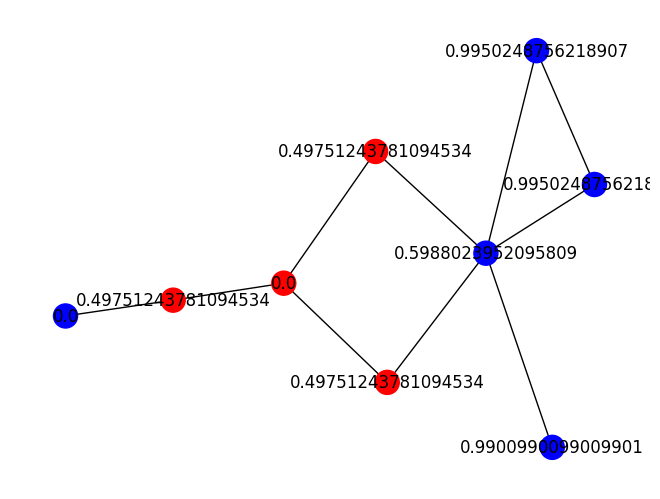

In [11]:
c = []
for node,attr in G1.nodes.items():
    c.append(cols[attr['Y']])

labeldict = {}
for node,attr in G1.nodes.items():
    labeldict[node] = attr['F2']
pos=nx.kamada_kawai_layout(G1)
nx.draw(G1, pos,node_color=c, labels=labeldict, with_labels=True)

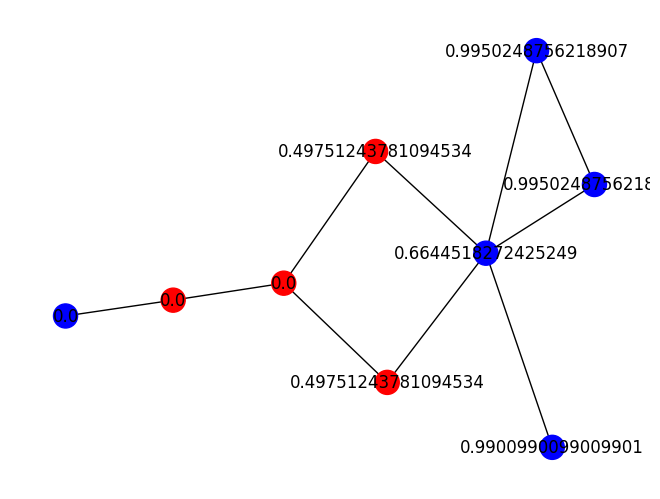

In [12]:

labeldict = {}
for node,attr in G.nodes.items():
    labeldict[node] = attr['F2']
pos=nx.kamada_kawai_layout(G)
nx.draw(G, pos,node_color=c, labels=labeldict, with_labels=True)

### Другой вариант веса

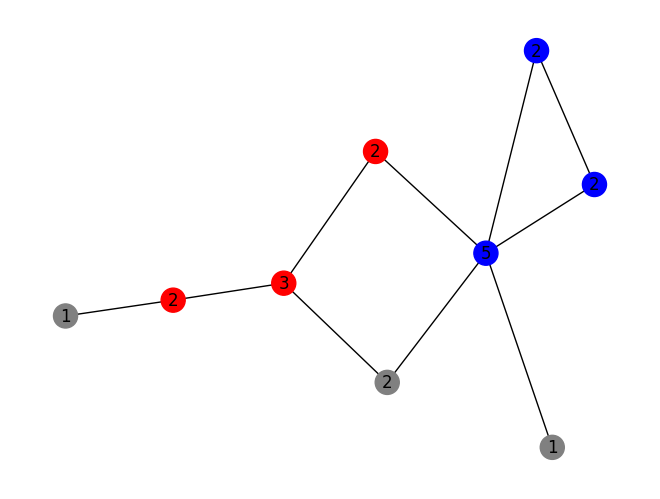

In [13]:
import networkx as nx
G=nx.Graph()
G.add_nodes_from([(0,{'Y':1,'train':1,'F':2}),(1,{'Y':1,'train':1,'F':5}),(2,{'Y':1,'train':1,'F':2}),
                  (3,{'Y':0,'train':1,'F':3}),(4,{'Y':0,'train':1,'F':2}),(5,{'Y':0,'train':1,'F':2}),
                  (6,{'Y':-1,'train':0,'F':2}),(7,{'Y':-1,'train':0,'F':1}),(8,{'Y':-1,'train':0,'F':1}),
                  ])
G.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(3,6),(1,5),(1,6),(1,7),(4,8)])
cols={-1:'gray',0:'red',1:'blue'}
c = []
for node,attr in G.nodes.items():
    c.append(cols[attr['Y']])

labeldict = {}
for node,attr in G.nodes.items():
    labeldict[node] = attr['F']

pos=nx.kamada_kawai_layout(G)
nx.draw(G, pos,node_color=c, labels=labeldict, with_labels=True)

In [14]:
import numpy as np
### Train F1
x1,y1=[],[]
for n in G.nodes():
  if G.nodes[n]['train']==1:
    x1.append(G.nodes[n]['F'])
    y1.append(G.nodes[n]['Y'])
print(x1,y1)
x1=np.array(x1)[:,np.newaxis]
y1=np.array(y1)
from sklearn.tree import DecisionTreeClassifier
def f1(x1,y1):
 clf=DecisionTreeClassifier(max_depth=1)
 clf.fit(x1,y1)
 return clf
clf1=f1(x1,y1)
print(clf1.score(x1,y1))

[2, 5, 2, 3, 2, 2] [1, 1, 1, 0, 0, 0]
0.6666666666666666


In [15]:
### train F2
### summary: mean labels
x2,y2=[],[]
nsel=[1]*6+[0]*3
print('nsel',nsel)
for n in G.nodes():
    zacc=[]
    for n_n in G.neighbors(n):
      if nsel[n_n]==1:
       if G.nodes[n_n]['train']==1:
        zacc.append(G.nodes[n_n]['Y'])
       else:
        zacc.append(int(clf1.predict([[G.nodes[n_n]['F']]])[0]))
#    print(n,zacc)
    zm=np.array(zacc)
    G.nodes[n]['F2']=float(zm.sum()/(zm.shape[0]+1e-2))

for n in G.nodes():
 if nsel[n]==1:
    x2.append([G.nodes[n]['F2']])
    if(G.nodes[n]['train']==1):
     y2.append(G.nodes[n]['Y'])
    else:
     y2.append(clf1.predict([[G.nodes[n]['F']]])[0])

x2=np.array(x2)
y2=np.array(y2)
print(x2,y2)

def f2(x2,y2):
 clf=DecisionTreeClassifier(max_depth=1)
 clf.fit(x2,y2)
 return clf
clf2=f2(x2,y2)
print(clf2.score(x2,y2))

nsel [1, 1, 1, 1, 1, 1, 0, 0, 0]
[[0.99502488]
 [0.66445183]
 [0.99502488]
 [0.        ]
 [0.        ]
 [0.49751244]] [1 1 1 0 0 0]
1.0


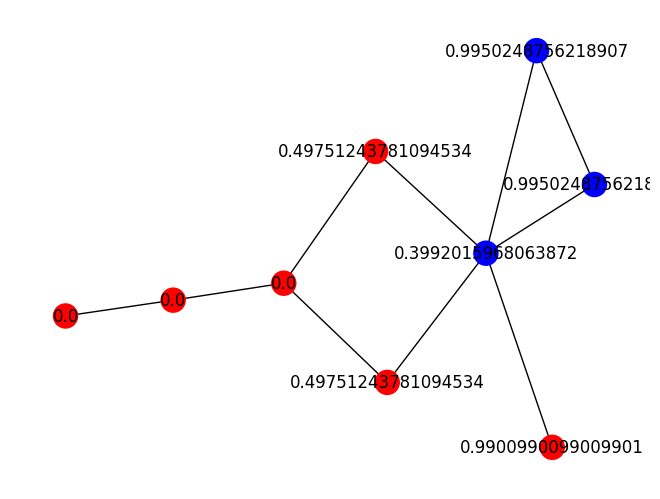

In [16]:
G1=G.copy()
for itt in range(1000):
# x1,y1=[],[]
 for n in G1.nodes():
    if G1.nodes[n]['train']!=1:
      G1.nodes[n]['Y']=int(clf1.predict([[G1.nodes[n]['F']]])[0])
 for n in G1.nodes():
    zacc=[]
    for n_n in G1.neighbors(n):
#      if nsel[n_n]!=1:
        zacc.append(G1.nodes[n_n]['Y'])
    zm=np.array(zacc)
    G1.nodes[n]['F2']=float(zm.sum()/(zm.shape[0]+1e-2))
c = []
for node,attr in G1.nodes.items():
    c.append(cols[attr['Y']])

labeldict = {}
for node,attr in G1.nodes.items():
    labeldict[node] = attr['F2']
pos=nx.kamada_kawai_layout(G1)
nx.draw(G1, pos,node_color=c, labels=labeldict, with_labels=True)